In [1]:
import random
import math
import matplotlib.pyplot as plt

def get_cities(filename):
    with open(filename) as f:
        return [[line.split()[0], float(line.split()[1]), float(line.split()[2])] for line in f]

def calculate_distance(city1, city2):
    return math.sqrt((city2[1] - city1[1])**2 + (city2[2] - city1[2])**2)

def calculate_total_distance(cities):
    return sum(calculate_distance(cities[i], cities[i+1]) for i in range(len(cities) - 1)) + calculate_distance(cities[0], cities[-1])

def select_population(cities, size):
    population = []
    for _ in range(size):
        c = cities.copy()
        random.shuffle(c)
        population.append([calculate_total_distance(c), c])
    return population, sorted(population)[0]

def crossover(parent1, parent2, point):
    child1 = parent1[:point] + [city for city in parent2 if city not in parent1[:point]]
    child2 = parent2[:point] + [city for city in parent1 if city not in parent2[:point]]
    return child1, child2

def mutate(chromosome, mutation_rate):
    if random.random() < mutation_rate:
        p1, p2 = random.sample(range(len(chromosome)), 2)
        chromosome[p1], chromosome[p2] = chromosome[p2], chromosome[p1]
    return chromosome

In [2]:
def genetic_algorithm(cities, pop_size, tournament_size, mutation_rate, crossover_rate, target, generations=200):
    population, first_fittest = select_population(cities, pop_size)
    for gen in range(generations):
        population = sorted(population)
        new_population = population[:2]
        for _ in range((pop_size - 2) // 2):
            if random.random() < crossover_rate:
                parent1 = random.choices(sorted(population)[:tournament_size], k=1)[0][1]
                parent2 = random.choices(sorted(population)[:tournament_size], k=1)[0][1]
                child1, child2 = crossover(parent1, parent2, random.randint(0, len(cities) - 1))
            else:
                child1, child2 = random.choice(population)[1], random.choice(population)[1]
            new_population.extend([[calculate_total_distance(mutate(child1, mutation_rate)), child1],
                                   [calculate_total_distance(mutate(child2, mutation_rate)), child2]])
        population = new_population
        if gen % 10 == 0:
            print(f"{gen}, {sorted(population)[0][0]}")
        if sorted(population)[0][0] < target:
            break
    return sorted(population)[0], gen

0, 1429.1080262389276
10, 1143.2854236170929
20, 1020.8147246744054
30, 950.0934256226653
40, 898.9159165027293
50, 836.9523656980837
60, 795.864691199733
70, 774.8397283880106
80, 720.5037098609678
90, 720.5037098609678
100, 679.0338941698978
110, 674.3138245287586
120, 663.7834643548495
130, 663.7834643548495
140, 663.7834643548495
150, 662.8631089620694
160, 662.8631089620694
170, 650.7664727803277
180, 640.1443619792594
190, 640.1443619792594

----------------------------------------------------------------
Generation: 199
Fittest chromosome distance before training: 1349.9482122284883
Fittest chromosome distance after training: 632.2363394903213
Target distance: 450.0
----------------------------------------------------------------



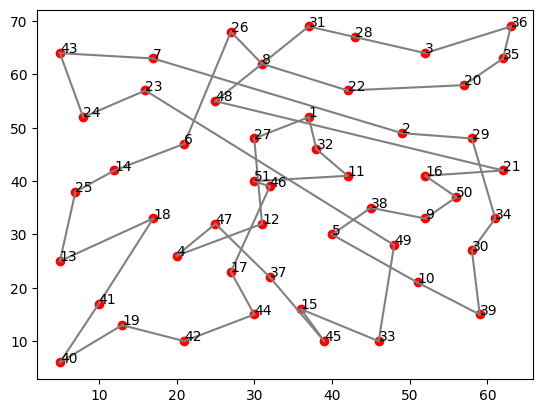

In [3]:
def draw_map(cities, answer):
    plt.plot([city[1] for city in cities], [city[2] for city in cities], 'ro')
    for city in cities:
        plt.annotate(city[0], (city[1], city[2]))
    for i in range(len(answer[1]) - 1):
        plt.plot([answer[1][i][1], answer[1][i + 1][1]], [answer[1][i][2], answer[1][i + 1][2]], 'gray')
    plt.plot([answer[1][0][1], answer[1][-1][1]], [answer[1][0][2], answer[1][-1][2]], 'gray')
    plt.show()

def main():
    pop_size, tournament_size, mutation_rate, crossover_rate, target = 100, 4, 0.1, 0.9, 450.0
    cities = get_cities("TSP51.txt")
    population, first_fittest = select_population(cities, pop_size)
    answer, gen_number = genetic_algorithm(cities, pop_size, tournament_size, mutation_rate, crossover_rate, target)
    print("\n----------------------------------------------------------------")
    print("Generation: " + str(gen_number))
    print("Fittest chromosome distance before training: " + str(first_fittest[0]))
    print("Fittest chromosome distance after training: " + str(answer[0]))
    print("Target distance: " + str(target))
    print("----------------------------------------------------------------\n")
    draw_map(cities, answer)

#if __name__ == "__main__":
main()